In [1]:
import pandas as pd
import matplotlib.pyplot as plt

前5行数据：
   ID  State Code  County Code  Site Num                      Address  \
0   1           6           37      1103  1630 N MAIN ST, LOS ANGELES   
1   2           6           37      1103  1630 N MAIN ST, LOS ANGELES   
2   3           6           37      1103  1630 N MAIN ST, LOS ANGELES   
3   4           6           37      1103  1630 N MAIN ST, LOS ANGELES   
4   5           6           37      1103  1630 N MAIN ST, LOS ANGELES   

        State       County         City Date Local          SO2 Units  \
0  California  Los Angeles  Los Angeles   2006/1/1  Parts per billion   
1  California  Los Angeles  Los Angeles   2006/1/1  Parts per billion   
2  California  Los Angeles  Los Angeles   2006/1/1  Parts per billion   
3  California  Los Angeles  Los Angeles   2006/1/1  Parts per billion   
4  California  Los Angeles  Los Angeles   2006/1/2  Parts per billion   

   SO2 Mean  SO2 1st Max Value  SO2 1st Max Hour  SO2 AQI  
0  2.043478                3.0                 5      4

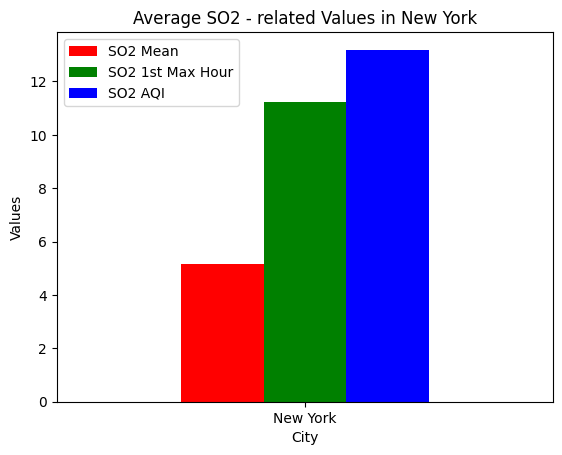

In [2]:
# 任务（1）
def task1():
    csv_file_path = 'pollution_us_5city_2006_2010_SO2.csv'
    try:
        df = pd.read_csv(csv_file_path)
        print("前5行数据：")
        print(df.head(5))
        print("后2行数据：")
        print(df.tail(2))
    except FileNotFoundError:
        print(f"文件 {csv_file_path} 未找到，请检查路径。")


# 任务（2）
def task2():
    csv_file_path = 'pollution_us_5city_2006_2010_SO2.csv'
    excel_file_path = 'pollution_us_5city_2006_2010_SO2.xlsx'
    try:
        df = pd.read_csv(csv_file_path)
        # 删除指定列
        df = df.drop(['State Code', 'County Code', 'Site Num', 'Address'], axis=1)
        # 仅处理数值列的缺失值
        numerical_cols = df.select_dtypes(include=['number']).columns
        for col in numerical_cols:
            df[col] = df[col].fillna(df[col].mean())
            df.to_excel(excel_file_path, index=False)
    except FileNotFoundError:
        print(f"文件 {csv_file_path} 或 {excel_file_path} 未找到，请检查路径。")


# 任务（3）
def task3():
    excel_file_path = 'pollution_us_5city_2006_2010_SO2.xlsx'
    txt_file_path = 'pollution_us_NewYork_2006_2010_SO2.txt'
    try:
        df = pd.read_excel(excel_file_path)
        # 筛选纽约市数据
        new_york_df = df[df['City'] == 'New York']
        # 保存时包含索引
        new_york_df.to_csv(txt_file_path, sep=' ', index=True)
    except FileNotFoundError:
        print(f"文件 {excel_file_path} 或 {txt_file_path} 未找到，请检查路径。")


# 任务（4）
def task4():
    txt_file_path = 'pollution_us_NewYork_2006_2010_SO2.txt'
    csv_file_path = 'pollution_us_NewYork_2007_2009_SO2.csv'
    try:
        # 读取时处理索引列
        df = pd.read_csv(txt_file_path, sep=' ', index_col=0)
        # 转换日期格式
        df['Date Local'] = pd.to_datetime(df['Date Local'])
        # 筛选日期范围
        selected_df = df[(df['Date Local'] >= '2007-01-01') & (df['Date Local'] <= '2009-12-31')]
        selected_df.to_csv(csv_file_path, index=False)
    except FileNotFoundError:
        print(f"文件 {txt_file_path} 或 {csv_file_path} 未找到，请检查路径。")


# 任务（5）
def task5():
    csv_file_path = 'pollution_us_NewYork_2007_2009_SO2.csv'
    try:
        df = pd.read_csv(csv_file_path)
        # 分组统计平均值
        grouped_df = df.groupby('City')[['SO2 Mean', 'SO2 1st Max Hour', 'SO2 AQI']].mean()
        # 绘制柱状图
        grouped_df.plot(kind='bar', color=['r', 'g', 'b'])
        plt.title('Average SO2 - related Values in New York')
        plt.xlabel('City')
        plt.ylabel('Values')
        plt.xticks(rotation=0)
        plt.show()
    except FileNotFoundError:
        print(f"文件 {csv_file_path} 未找到，请检查路径。")


if __name__ == "__main__":
    task1()
    task2()
    task3()
    task4()
    task5()

    year  month   SO2 Mean
0   2007      1  10.861478
1   2007      2  12.903617
2   2007      3   7.503241
3   2007      4   4.681641
4   2007      5   3.298819
5   2007      6   2.848133
6   2007      7   3.276636
7   2007      8   2.753549
8   2007      9   2.385794
9   2007     10   3.534504
10  2007     11   6.242173
11  2007     12   7.596761
12  2008      1   9.910129
13  2008      2   8.610304
14  2008      3   5.117550
15  2008      4   3.344476
16  2008      5   2.646978
17  2008      6   3.221686
18  2008      7   3.238548
19  2008      8   2.042838
20  2008      9   1.700875
21  2008     10   4.554874
22  2008     11   5.980943
23  2008     12   7.541023
24  2009      1  11.073168
25  2009      2   8.423490
26  2009      3   5.960416
27  2009      4   3.866358
28  2009      5   1.948221
29  2009      6   1.311233
30  2009      7   1.763219
31  2009      8   2.072466
32  2009      9   1.639808
33  2009     10   3.241540
34  2009     11   3.872645
35  2009     12   7.056360
0

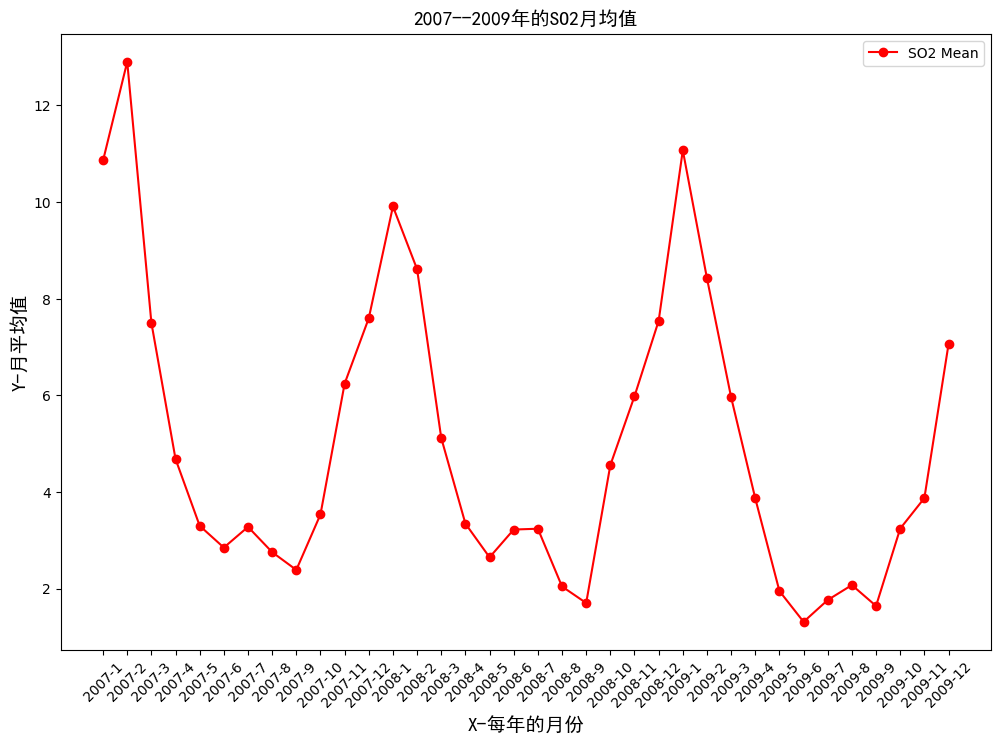

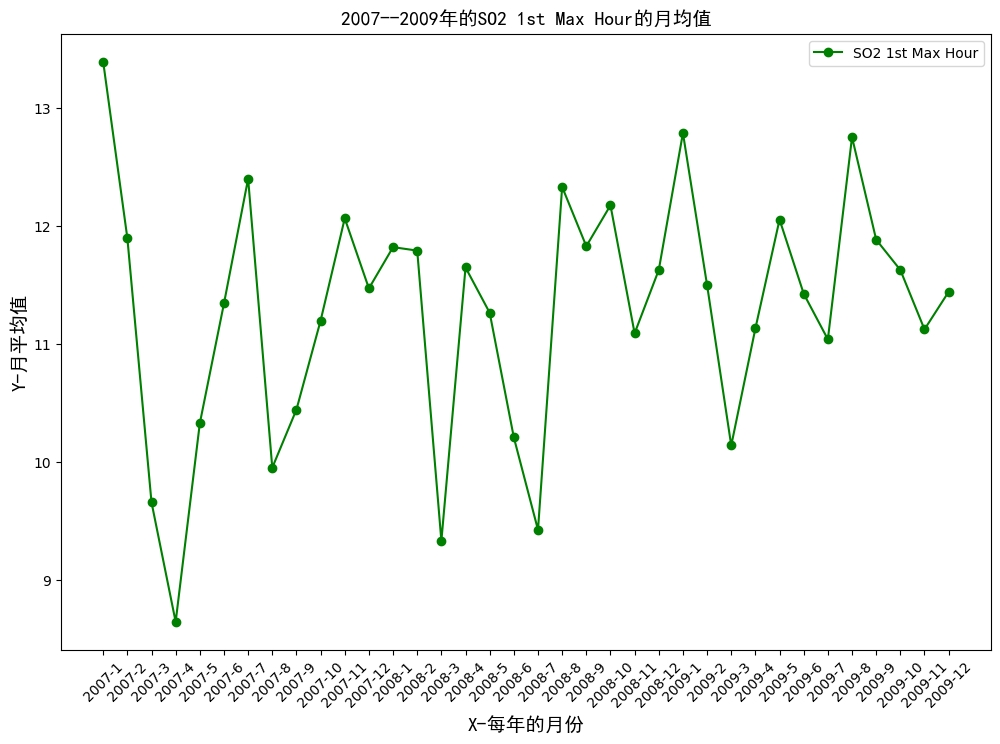

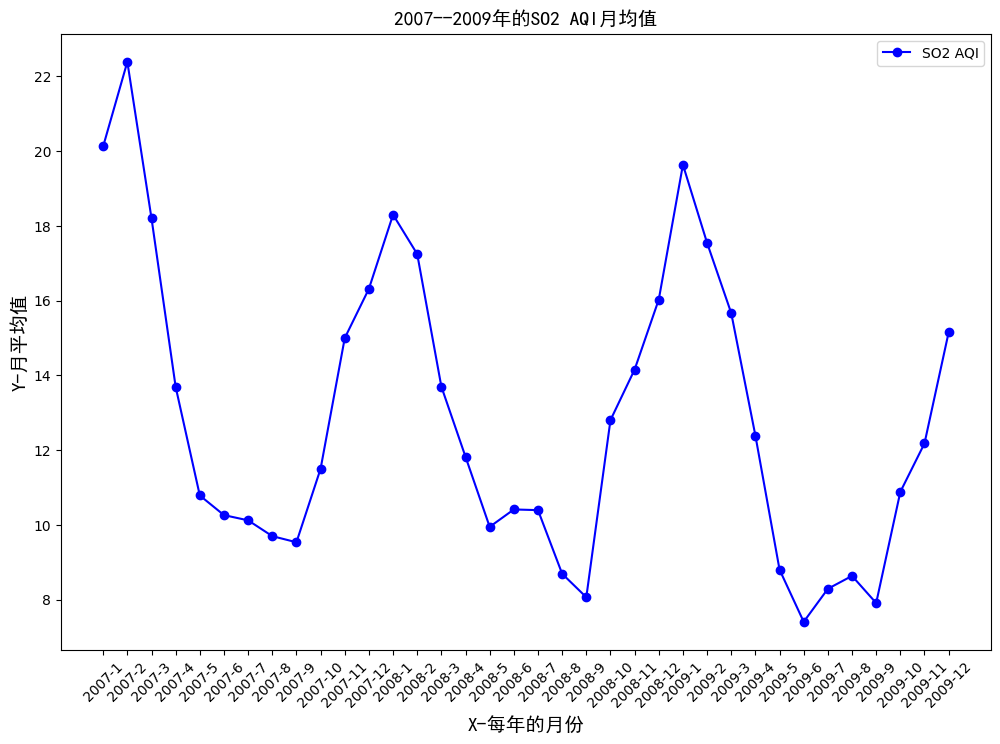

任务5执行成功！


In [7]:
filename = 'pollution_us_NewYork_2007_2009_SO2.csv'
df = pd.read_csv(filename, encoding='cp936')
df['year'] = df['Date Local'].map(lambda x: int(x[0:x.index('-')]))
df['month'] = df['Date Local'].map(lambda x: int(x[5:x.rindex('-')]))
df_mean1 = df.loc[:, ['SO2 Mean', 'year', 'month']]
df_mean2 = df.loc[:, ['SO2 1st Max Hour', 'year', 'month']]
df_mean3 = df.loc[:, ['SO2 AQI', 'year', 'month']]
df_mean1_groupby = df_mean1.groupby(['year', 'month'], as_index=False).mean()
df_mean2_groupby = df_mean2.groupby(['year', 'month'], as_index=False).mean()
df_mean3_groupby = df_mean3.groupby(['year', 'month'], as_index=False).mean()
df1 = df_mean1_groupby.sort_values(['year', 'month'])  # 按照月份从小到大排序
df2 = df_mean2_groupby.sort_values(['year', 'month'])  # 按照月份从小到大排序
df3 = df_mean3_groupby.sort_values(['year', 'month'])  # 按照月份从小到大排序
df1.to_csv('SO2_Mean.csv', encoding='cp936', index=False)  # 将月平均放到一个新的csv文件中方便作图
df2.to_csv('SO2_1st_Max_Hour.csv', encoding='cp936', index=False)  # 将月平均放到一个新的csv文件中方便作图
df3.to_csv('SO2_AQI.csv', encoding='cp936', index=False)  # 将月平均放到一个新的csv文件中方便作图

df_new1 = pd.read_csv('SO2_Mean.csv', encoding='cp936')  # 读文件
print(df_new1)
df_new1['SO2 Mean1'] = df_new1['SO2 Mean'].map(lambda x: float(x))
df_new1['year-month'] = df_new1['year'].map(lambda x: str(x)) + '-' + df_new1['month'].map(lambda x: str(x))
print(df_new1['year-month'])
plt.figure(figsize=(12, 8))  # 作图的大小
plt.plot(range(len(list(df_new1['year-month']))), df_new1['SO2 Mean1'], color='red', marker='o', label='SO2 Mean')
plt.xticks(range(len(list(df_new1['year-month']))), list(df_new1['year-month']), rotation=45)
plt.title('2007--2009年的SO2月均值', fontproperties='SimHei', fontsize=14)
plt.xlabel('X-每年的月份', fontproperties='SimHei', fontsize=14)
plt.ylabel('Y-月平均值', fontproperties='SimHei', fontsize=14)
plt.legend()
plt.savefig('SO2_Mean.png', dpi=300)
plt.show()

df_new2 = pd.read_csv('SO2_1st_Max_Hour.csv', encoding='cp936')  # 读文件

df_new2['SO2 1st Max Hour2'] = df_new2['SO2 1st Max Hour'].map(lambda x: float(x))
df_new2['year-month'] = df_new2['year'].map(lambda x: str(x)) + '-' + df_new2['month'].map(lambda x: str(x))
plt.figure(figsize=(12, 8))  # 作图的大小
plt.plot(range(len(list(df_new2['year-month']))), df_new2['SO2 1st Max Hour2'], color='green', marker='o', label='SO2 1st Max Hour')
plt.xticks(range(len(list(df_new2['year-month']))), list(df_new2['year-month']), rotation=45)
plt.title('2007--2009年的SO2 1st Max Hour的月均值', fontproperties='SimHei', fontsize=14)
plt.xlabel('X-每年的月份', fontproperties='SimHei', fontsize=14)
plt.ylabel('Y-月平均值', fontproperties='SimHei', fontsize=14)
plt.legend()
plt.savefig('SO2_1st_Max_Hour.png', dpi=300)
plt.show()

df_new3 = pd.read_csv('SO2_AQI.csv', encoding='cp936')  # 读文件
df_new3['SO2 AQI3'] = df_new3['SO2 AQI'].map(lambda x: float(x))
df_new3['year-month'] = df_new3['year'].map(lambda x: str(x)) + '-' + df_new3['month'].map(lambda x: str(x))
plt.figure(figsize=(12, 8))  # 作图的大小
plt.plot(range(len(list(df_new3['year-month']))), df_new3['SO2 AQI3'], color='blue', marker='o', label='SO2 AQI')
plt.xticks(range(len(list(df_new3['year-month']))), list(df_new3['year-month']), rotation=45)
plt.title('2007--2009年的SO2 AQI月均值', fontproperties='SimHei', fontsize=14)
plt.xlabel('X-每年的月份', fontproperties='SimHei', fontsize=14)
plt.ylabel('Y-月平均值', fontproperties='SimHei', fontsize=14)
plt.legend()
plt.savefig('SO2 AQI.png', dpi=300)
plt.show()
print('任务5执行成功！')